In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns


#Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [5]:
#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

def clean_skills(x):
    if isinstance(x, list):
        return x
    elif pd.isna(x):
        return []
    elif isinstance(x, str):
        return ast.literal_eval(x)
    else:
        return []

df["job_skills_clean"] = df["job_skills"].apply(clean_skills)

In [6]:
# Can job skills and role information predict whether a data job is remote?
top_roles = ["Data Analyst","Data Engineer","Data Scientist"]
model_df = df[(df["job_title_short"].isin(top_roles)) &(df["job_skills_clean"].map(len) > 0)].copy()

# Drop highly sparse salary columns
model_df = model_df.drop(columns=["salary_hour_avg","salary_year_avg","salary_rate","job_title"])
model_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 474563 entries, 1 to 785739
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        474563 non-null  object        
 1   job_location           473909 non-null  object        
 2   job_via                474555 non-null  object        
 3   job_schedule_type      466637 non-null  object        
 4   job_work_from_home     474563 non-null  bool          
 5   search_location        474563 non-null  object        
 6   job_posted_date        474563 non-null  datetime64[ns]
 7   job_no_degree_mention  474563 non-null  bool          
 8   job_health_insurance   474563 non-null  bool          
 9   job_country            474552 non-null  object        
 10  company_name           474554 non-null  object        
 11  job_skills             474563 non-null  object        
 12  job_type_skills        474563 non-null  object   

In [7]:
# The target variable 
y = model_df["job_work_from_home"]
y

1         False
2         False
3         False
4         False
5          True
          ...  
785730    False
785731    False
785732    False
785737    False
785739    False
Name: job_work_from_home, Length: 474563, dtype: bool

In [8]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

In [9]:
skills_encoded = mlb.fit_transform(model_df["job_skills_clean"])

skills_encoded_df = pd.DataFrame(skills_encoded,columns=mlb.classes_,index=model_df.index)

In [10]:
role_dummies = pd.get_dummies(model_df["job_title_short"],drop_first=True)

In [11]:
X = pd.concat([skills_encoded_df, role_dummies],axis=1)

y = model_df["job_work_from_home"]

In [13]:
# Check feature matrix and target
print("X shape:", X.shape)
print("y shape:", y.shape)

# Check class balance
print(y.value_counts())
print(y.value_counts(normalize=True))

X shape: (474563, 250)
y shape: (474563,)
job_work_from_home
False    429742
True      44821
Name: count, dtype: int64
job_work_from_home
False    0.905553
True     0.094447
Name: proportion, dtype: float64


In [14]:
#remove very rare skills/features

min_count = 100

valid_features = X.sum(axis=0) >= min_count
X_filtered = X.loc[:, valid_features]

print("Original X shape:", X.shape)
print("Filtered X shape:", X_filtered.shape)

Original X shape: (474563, 250)
Filtered X shape: (474563, 195)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_filtered,y,test_size=0.2,random_state=42, stratify=y)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6188930915680676
ROC-AUC: 0.6278908496938781

Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.63      0.75     85949
        True       0.13      0.56      0.22      8964

    accuracy                           0.62     94913
   macro avg       0.53      0.59      0.48     94913
weighted avg       0.86      0.62      0.70     94913



In [20]:
# Interpreting logistic regression coefficients

coef_df = pd.DataFrame({"feature": X_train.columns,"coefficient": model.coef_[0]})

top_positive = coef_df.sort_values("coefficient",ascending=False).head(20).reset_index()

top_negative = coef_df.sort_values("coefficient",ascending=True).head(20)

top_positive,

(    index        feature  coefficient
 0       6           arch     0.875879
 1     145         sheets     0.708819
 2      82        laravel     0.695082
 3     172         twilio     0.637431
 4     147          slack     0.600054
 5       1       airtable     0.516260
 6     192           zoom     0.505216
 7     148     smartsheet     0.495638
 8     101        node.js     0.474103
 9      84         looker     0.455932
 10     31        crystal     0.443390
 11     63         golang     0.437424
 12    112        phoenix     0.402415
 13    193  Data Engineer     0.393442
 14     91     monday.com     0.392066
 15    110         pandas     0.385650
 16     69   hugging face     0.354574
 17    125        pytorch     0.347032
 18    136           rust     0.339763
 19      7          asana     0.335935,)

In [22]:
top_negative.reset_index()

,index,feature,coefficient
0,70,ibm cloud,-1.766404
1,27,colocation,-1.097307
2,130,redhat,-1.093908
3,5,apl,-0.869551
4,184,vue,-0.866834
5,133,rshiny,-0.747582
6,182,visual basic,-0.734970
7,186,watson,-0.694904
8,118,powerbi,-0.649315
9,8,asp.net,-0.617312


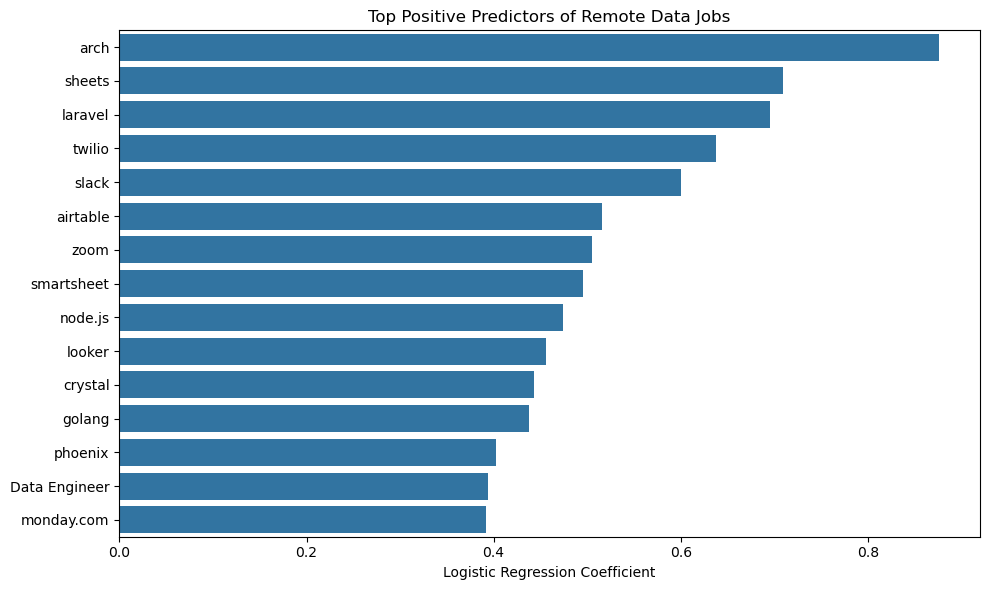

In [30]:
top_positive = (coef_df.sort_values("coefficient", ascending=False).head(15))

plt.figure(figsize=(10, 6))

sns.barplot(data=top_positive, x="coefficient", y="feature",order=top_positive["feature"])

plt.title("Top Positive Predictors of Remote Data Jobs")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("")

plt.tight_layout()
plt.show()